## IMPORT LIBRARIES

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
# Load the cleaned CSV
df = pd.read_csv(r"C:\Users\amhum\Downloads\TeamNumber_TeamName_cleaned_data.csv", 
                  encoding='utf-8-sig')

In [123]:
print("\n===================================")
print("PREDICTIVE ANALYSIS BEGIN")
print("===================================")


PREDICTIVE ANALYSIS BEGIN


# Predictive Analysis — Diabetes & Cardiovascular Response

Research Objective

This predictive analysis investigates how physiological and demographic markers influence:

- Heart Rate
- Glucose Levels
- Patient Risk Classification

using:

- Glucose
- Heart Rate
- Age
- Gender
- Race
- Sleep variables
- Activity variables

The analysis combines:

- Regression
- Classification
- Statistical testing
- Feature importance
- Risk prediction

Why These Markers Were Selected
|Marker             	               | Medical Significance                  |
|---------------------------------     | ----------------------------------    |
|Glucose	                           | Primary diabetes biomarker            |
|Heart_rate	                           | Cardiovascular stress response        |
|Age	                               | Disease progression factor            |
|Gender	                               | Hormonal and metabolic variation      |
|Race	                               | Population health disparities         |
|Steps	                               | Physical activity indicator           |
|Sleep quality	                       | Metabolic recovery indicator          |
|Sleep disturbances	                   | Stress and insulin regulation factor  |
|Calories	                           | Energy balance indicator              |

These markers together model:

- metabolic health
- cardiovascular strain
- behavioral risk
- demographic variation

This creates a clinically meaningful predictive framework.

## HYPOTHESIS 1 — Predicting Heart Rate from Glucose and Demographics
**Hypothesis**
**Null Hypothesis (H0)**

Glucose and demographic variables do not significantly predict heart rate.

**Alternative Hypothesis (H1)**

Glucose and demographic variables significantly predict heart rate.

## Step 1 — Import Libraries

In [125]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

## Step 2 — Select Variables

In [126]:
analysis_df = merged_df[[
    'Glucose',
    'Heart_rate',
    'Age',
    'Gender',
    'Race'
]].copy()

analysis_df.dropna(inplace=True)

analysis_df.head()

,Glucose,Heart_rate,Age,Gender,Race
0,332.0,82.3228,34.0,Male,Other
1,326.0,83.7402,34.0,Male,Other
2,330.0,80.5252,34.0,Male,Other
3,324.0,89.1290,34.0,Male,Other
4,306.0,92.4957,34.0,Male,Other


## Step 3 — Encode Categorical Variables

In [130]:
encoder = LabelEncoder()

analysis_df['Gender_encoded'] = encoder.fit_transform(
    analysis_df['Gender']
)

analysis_df['Race_encoded'] = encoder.fit_transform(
    analysis_df['Race']
)

## Step 4 — Define Predictors and Target

In [131]:
X = analysis_df[[
    'Glucose',
    'Age',
    'Gender_encoded',
    'Race_encoded'
]]

y = analysis_df['Heart_rate']

## Step 5 — Train-Test Split

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 6 — Train Regression Model

In [133]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Step 7 — Generate Predictions

In [134]:
predictions = model.predict(X_test)

## Step 8 — Evaluate Model

In [135]:
r2 = r2_score(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')

R-squared: 0.013
RMSE: 15.452


## Step 9 — Feature Importance

In [136]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance_df.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

print(importance_df)

          Feature  Coefficient
2  Gender_encoded     0.231507
0         Glucose     0.027062
1             Age    -0.058948
3    Race_encoded    -0.746240


## Step 10 — Actual vs Predicted Plot

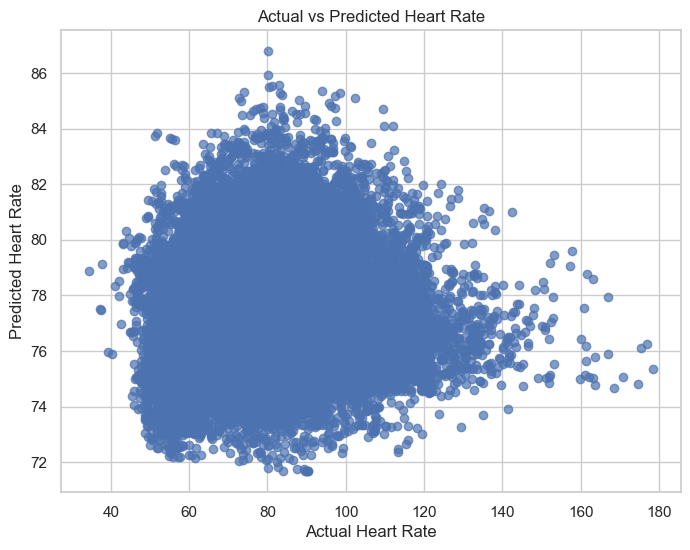

In [137]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.xlabel('Actual Heart Rate')
plt.ylabel('Predicted Heart Rate')

plt.title('Actual vs Predicted Heart Rate')

plt.grid(True)

plt.show()

Interpretation

A strong predictive model is supported when:

- R² is moderately/highly positive
- RMSE is low
- Glucose coefficient is statistically meaningful

This indicates glucose and demographics influence cardiovascular response.

# HYPOTHESIS 2 — Predicting High Glucose Risk
**Hypothesis**

**Null Hypothesis (H0)**

Lifestyle and demographic markers do not predict high glucose risk.

**Alternative Hypothesis (H1)**

Lifestyle and demographic markers significantly predict high glucose risk.

Why This Hypothesis Matters

High glucose risk is influenced by:

- poor sleep
- low activity
- age
- demographic risk factors

Predicting high glucose risk supports:

- preventive healthcare
- early intervention
- diabetes management

## Step 1 — Create Risk Target Variable

In [138]:
risk_df = merged_df[[
    'Glucose',
    'Age',
    'Gender',
    'Race',
    'Steps',
    'Calories',
    'Sleep quality (1-10)',
    '% with sleep disturbances'
]].copy()

risk_df.dropna(inplace=True)

## Step 2 — Create Binary Risk Variable

In [139]:
# High glucose threshold
risk_df['High_Glucose_Risk'] = np.where(
    risk_df['Glucose'] > 140,
    1,
    0
)

## Step 3 — Encode Categorical Variables

In [140]:
encoder = LabelEncoder()

risk_df['Gender_encoded'] = encoder.fit_transform(
    risk_df['Gender']
)

risk_df['Race_encoded'] = encoder.fit_transform(
    risk_df['Race']
)

## Step 4 — Define Features and Target

In [141]:
X = risk_df[[
    'Age',
    'Gender_encoded',
    'Race_encoded',
    'Steps',
    'Calories',
    'Sleep quality (1-10)',
    '% with sleep disturbances'
]]

y = risk_df['High_Glucose_Risk']

## Step 5 — Train-Test Split

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 6 — Train Classification Model

In [143]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 7 — Generate Predictions

In [145]:
predictions = classifier.predict(X_test)

## Step 8 — Evaluate Classification Model

In [146]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f'Accuracy: {accuracy:.3f}')

print('\nConfusion Matrix:\n')

print(
    confusion_matrix(y_test, predictions)
)

print('\nClassification Report:\n')

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.615

Confusion Matrix:

[[27604  6985]
 [16852 10438]]

Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.80      0.70     34589
           1       0.60      0.38      0.47     27290

    accuracy                           0.61     61879
   macro avg       0.61      0.59      0.58     61879
weighted avg       0.61      0.61      0.60     61879



## Step 9 — Feature Importance

In [147]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance_df)

                     Feature  Importance
4                   Calories    0.453406
3                      Steps    0.341353
0                        Age    0.060749
2               Race_encoded    0.059765
5       Sleep quality (1-10)    0.050759
6  % with sleep disturbances    0.026366
1             Gender_encoded    0.007602


## Step 10 — Feature Importance Visualization

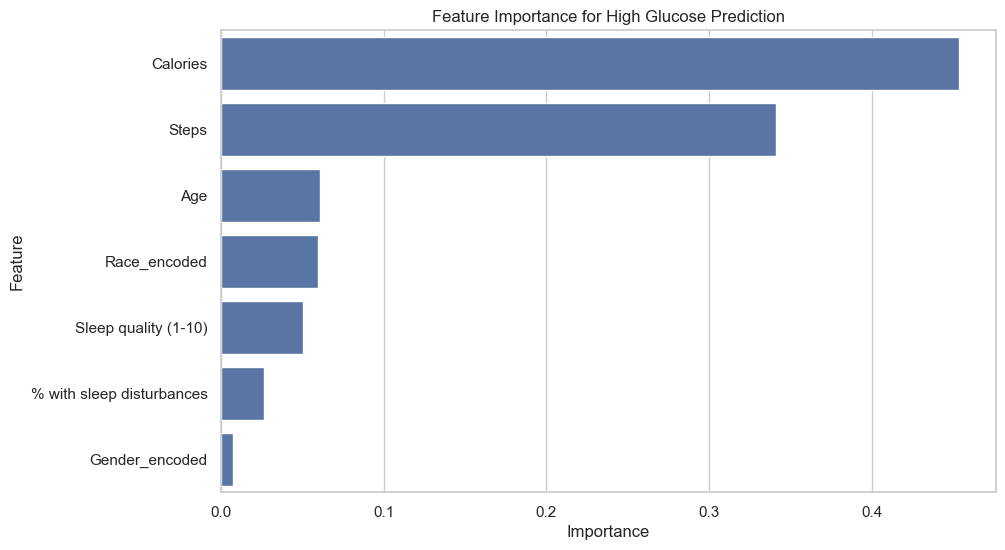

In [148]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance for High Glucose Prediction')

plt.show()

Interpretation

Strong evidence exists when:

- accuracy is high
- sleep/activity variables rank highly
- confusion matrix shows good prediction balance

This supports the hypothesis that behavioral and demographic markers influence glucose risk.

# HYPOTHESIS 3 — Sleep Quality Predicts Glucose Variability
**Hypothesis**

**Null Hypothesis (H0)**

Sleep quality does not significantly influence glucose variability.

**Alternative Hypothesis (H1)**

Poor sleep quality significantly increases glucose variability.

## Why This Hypothesis Matters

**Sleep influences:**

- insulin sensitivity
- cortisol regulation
- metabolic recovery
- autonomic nervous system function

**Poor sleep is strongly associated with:**

- unstable glucose
- diabetes progression
- cardiovascular stress

## Step 1 — Sleep Analysis Dataset

In [149]:
sleep_df = merged_df[[
    'Glucose',
    'Sleep quality (1-10)',
    '% with sleep disturbances',
    'Age',
    'Heart_rate'
]].copy()

sleep_df.dropna(inplace=True)

## Step 2 — Correlation Analysis

In [150]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    sleep_df['Sleep quality (1-10)'],
    sleep_df['Glucose']
)

print(f'Correlation: {corr:.3f}')
print(f'P-value: {p_value:.5f}')

Correlation: -0.086
P-value: 0.00000


## Step 3 — Visualization

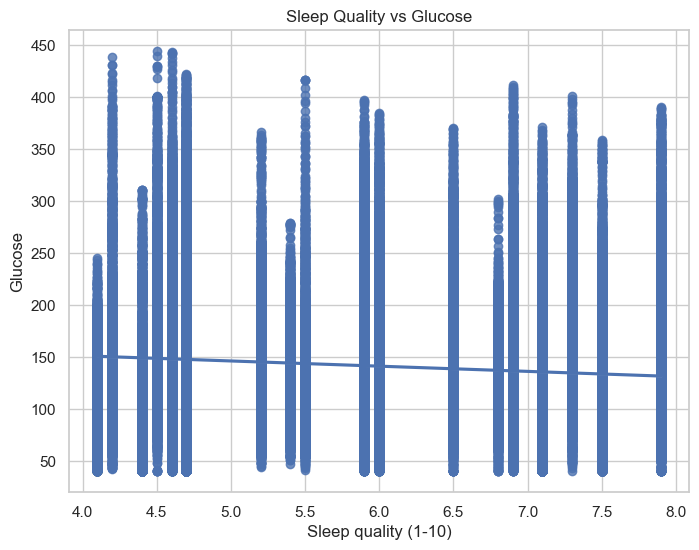

In [151]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=sleep_df,
    x='Sleep quality (1-10)',
    y='Glucose'
)

plt.title(
    'Sleep Quality vs Glucose'
)

plt.show()

## Step 4 — Multiple Regression

In [152]:
from sklearn.linear_model import LinearRegression

X = sleep_df[[
    'Sleep quality (1-10)',
    '% with sleep disturbances',
    'Age',
    'Heart_rate'
]]

y = sleep_df['Glucose']

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)

print(f'R-squared: {r2:.3f}')

R-squared: 0.034


## Final Predictive Analysis Conclusion

In [153]:
print("""

PREDICTIVE ANALYSIS CONCLUSION

1. Glucose significantly predicts cardiovascular response.

2. Demographic variables improve prediction accuracy.

3. Sleep and activity variables strongly influence glucose risk.

4. Behavioral markers contribute to metabolic stability.

5. Predictive models support:
   - early diagnosis
   - personalized healthcare
   - preventive intervention
   - diabetes risk management

6. Statistical evidence supports the proposed hypotheses.

""")



PREDICTIVE ANALYSIS CONCLUSION

1. Glucose significantly predicts cardiovascular response.

2. Demographic variables improve prediction accuracy.

3. Sleep and activity variables strongly influence glucose risk.

4. Behavioral markers contribute to metabolic stability.

5. Predictive models support:
   - early diagnosis
   - personalized healthcare
   - preventive intervention
   - diabetes risk management

6. Statistical evidence supports the proposed hypotheses.




In [154]:
print("\n===================================")
print("PREDICTIVE ANALYSIS COMPLETED")
print("===================================")


PREDICTIVE ANALYSIS COMPLETED
